# Week 04 seminar: Finetuning.

In [31]:
import os
import time
import requests
from tqdm.auto import trange, tqdm
from copy import deepcopy
from collections import defaultdict
import numpy as np
import pandas as pd

# charts and display libs
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display, HTML

# pytorch
import torch
import torchvision
from torchvision import transforms

device = torch.device('cuda:0' if torch.cuda.is_available() else
                      'mps:0' if torch.backends.mps.is_available() else 'cpu')

import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Ensure that output below says `device=device(type='cuda')` - you will need CUDA for faster model runs
# If in Colab, we recommend that you go to Runtime -> Change Runtime Type -> GPU

print(f"{torch.__version__=}, {torchvision.__version__=}, {device=}, {torch.get_num_threads()=}")

torch.__version__='2.11.0+cu130', torchvision.__version__='0.26.0+cu130', device=device(type='cuda', index=0), torch.get_num_threads()=1


## TorchVision

[Torchvision](https://pytorch.org/vision/main/index.html) - part of PyTorch library with convenient tools and data for deep learning in visual domain.
- contains a number of popular vision [datasets](https://pytorch.org/vision/stable/datasets.html)
- preprocessing [tools](https://pytorch.org/vision/stable/transforms.html)
- and most importantly, [pre-trained models](https://pytorch.org/vision/main/models.html).

# Datasets: Imagenet

![imagenet_tiles](https://i.imgur.com/n4QIrzF.jpeg)

Today we're going to use and fine-tune CNN based on weights pre-trained on ImageNet.

What is Imagenet?
- large size image classification dataset.
    - ImageNet-1K contains 1,281,167 training images, 50,000 validation images and 100,000 test images.
    - Full original dataset (ImageNet-21k) contains 14,197,122 images divided into 21,841 classes
    - Resolution varies, average resolution: 469x387 pixels
- built pre-2010 by [Fei-Fei Li](https://en.wikipedia.org/wiki/Fei-Fei_Li) at Princeton
- made very popular by ImageNet Large Scale Visual Recognition Challenge (ILSVRC). See AlexNet moment: [chart](https://www.researchgate.net/figure/ImageNet-Competition-Results-50_fig1_329975404), [wiki](https://en.wikipedia.org/wiki/AlexNet), [paper](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)
-  still relevant; [accuracy history 2013 to date](https://paperswithcode.com/sota/image-classification-on-imagenet)
- More about Imagenet: http://image-net.org/,  https://en.wikipedia.org/wiki/ImageNet

In [32]:
# loading Imagenet class labels for interpreting classification results
LABELS_URL = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
imagenet_labels = {int(k):v[1] for k, v in requests.get(LABELS_URL).json().items()}
print(len(imagenet_labels), '\n', list(imagenet_labels.items())[:5])

1000 
 [(0, 'tench'), (1, 'goldfish'), (2, 'great_white_shark'), (3, 'tiger_shark'), (4, 'hammerhead')]


# Pretrained models: Resnet


Torchvision models classification models with benchmarks may be viewed [here.](https://pytorch.org/vision/main/models.html#classification)

For this seminar we're going to use Pytorch implementation of popular Resnet model.

In [33]:
# loading pretrained Resnet-18 model
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT) # load model with best available weights
model = model.to(device)  # move the model to GPU if available
model.train(False);        # set the model to evaluation mode

In [34]:
# view the model structure. Familiar layers are combined into 4 blocks
# note the last LINEAR layer named 'fc' that converts embeddings of size 512 into logits for 1000 Imagenet classes
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### testing the pretrained model 1
test output dimensions with dummy inputs<br>
note that model inputs have to be 4D: (batch_size, color_channes, height, width)<br>
output is a 2D tensor of logits (batch_size, number_of_classes)

In [35]:
dummy_x = torch.randn(5, 3, 224, 224, device=device)  # dummy batch of 5 'images' sized 224x224 with 3 channels, created on GPU
result = model(dummy_x)
assert result.shape == (5, 1000)   # output is a 2D tensor of logits (batch_size, number_of_classes)

### testing the pretrained model 2. Predict class probabilities.

(224, 224)


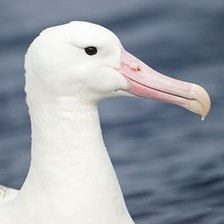

In [36]:
# loading image with PIL library
img = Image.open(requests.get('https://github.com/yandexdataschool/Practical_DL/blob/fall24/week04_finetuning/sample_images/albatross.jpg?raw=true', stream=True).raw)
# img = Image.open('sample_images/albatross.jpg')  # alternative source
print(img.size)
img

In [37]:
# converting PIL image to torch.Tensor - detailed process
img_torch = torch.tensor(np.array(img), device=device)  # convert PIL image to np.array, then to torch.Tensor,
img_torch = img_torch.permute(2,0,1)  # reorder channels to move color to the front position, to match pytorch conventions
img_torch = img_torch / img_torch.max()  # scale to 0..1

img_torch.shape, img_torch.device, img_torch.min().item(), img_torch.max().item()  # verify shape, device and range

(torch.Size([3, 224, 224]),
 device(type='cuda', index=0),
 0.007843137718737125,
 1.0)

In [38]:
# converting PIL image to torch.Tensor - easy process
# PIL image to torch.Tensor can be converted with torchvision.transforms, equivalent to the above code (more details below)
img_torch = transforms.ToTensor()(img)
img_torch.shape, img_torch.max(), img_torch.min()

(torch.Size([3, 224, 224]), tensor(1.), tensor(0.0078))

In [39]:
#changed
# Predicting image class with pretrained model

def predict_img(img, model, top_n=5):
    if isinstance(img, str):
        img = Image.open(requests.get(img, stream=True).raw).convert('RGB')  # for loading images from url

    img = img.convert("RGB")
    img_torch = transforms.ToTensor()(img)  # to torch.Tensor, reorder color channels, s|cale to 0..1
    img_torch = transforms.Resize((224, 224))(img_torch)      # another useful transform to resize images
    # used the normalization expected by the pretrained weights
    img_torch = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(img_torch)
    img_torch = img_torch.unsqueeze(0)                        # add batch dimension (remember that model needs 4D input)
    img_torch = img_torch.to(device)                          # moving the tensor to device (presumably cuda, in initialized above)
    model.eval()
    with torch.no_grad():
        prediction = model(img_torch)                             # obtain prediction logits from the model
    probs = torch.nn.functional.softmax(prediction, dim=-1)   # convert logits into probabilities
    probs = probs.detach().cpu().numpy()                          # convert CUDA tensor to numpy array

    top_ix = probs.ravel().argsort()[-1: -top_n - 1: -1]      # get indices of most probable classes
    print (f'top-{top_n} classes:')                           # look up class label
    for l in top_ix:
        print (f"{probs.ravel()[l]:>6.2%}  {imagenet_labels[l].split(',')[0]}")


predict_img(img, model)

top-5 classes:
99.48%  albatross
 0.45%  goose
 0.02%  white_stork
 0.01%  spoonbill
 0.01%  crane


### testing the pretrained model 3: Images from unknown classes

Play with imahes from these and other (yours) URLS. Note how object outsize of imagenet classes confuse the net. Low probabilities in top classes are indications of model's low confidence.

(1200, 790)


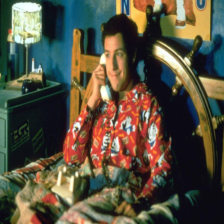

top-5 classes:
19.96%  pajama
 4.16%  drum
 4.15%  grocery_store
 3.78%  kimono
 3.32%  steel_drum


In [40]:
url= 'https://i.ebayimg.com/images/g/yDwAAOSwquxgTmcv/s-l1200.jpg'                    # modern version

# <TRY ANY OTHER IMAGES YOU LIKE>

web_img = Image.open(requests.get(url, stream=True).raw).convert('RGB')
print(web_img.size)
display(transforms.Resize((224, 224))(web_img))
predict_img(web_img, model)

## More Torchvision tools: Transforms and transform pipelines¶

You already used `transforms.ToTensor` and `transforms.Resize` above. There are many more at [Torchvision](https://pytorch.org/vision/stable/transforms.html). For easier application they are typically combined into pipelines. See examples below.

For more advanced tranforms (faster and compatible with tasks requiring mask or reference points), check out [Albumentations library](https://albumentations.ai/).

In [41]:
# Typical transform pipeline for test loop
transform_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Optional: normalize imaged according to ImageNet standards
])

img = Image.open(requests.get('https://github.com/yandexdataschool/Practical_DL/blob/fall24/week04_finetuning/sample_images/albatross.jpg?raw=true', stream=True).raw)
# img = Image.open('sample_images/albatross.jpg')  # alt link
img_torch = transform_pipeline(img)

print(type(img_torch), img_torch.shape)

<class 'torch.Tensor'> torch.Size([3, 224, 224])


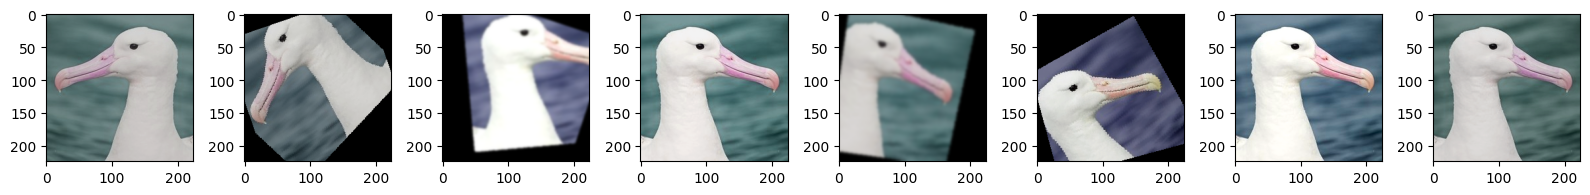

In [42]:
img = Image.open(requests.get('https://github.com/yandexdataschool/Practical_DL/blob/fall24/week04_finetuning/sample_images/albatross.jpg?raw=true', stream=True).raw)
# img = Image.open('sample_images/albatross.jpg')  # alternative source

# Demo of augmentations for train pipeline

transform_pipeline_2 = transforms.Compose([
    transforms.RandomCrop((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomApply([
        transforms.RandomAffine(degrees=30, translate=(0.2, 0.2)),
        transforms.RandomRotation(30),
        transforms.GaussianBlur(kernel_size=25),
    ], p=0.5),
    transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),  # not always applicable
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Optional: normalizes imaged according to ImageNet standards
])

fig, axs = plt.subplots(1, 8, figsize=(16, 4))
for i, ax in enumerate(axs.ravel()):
    img_2 = transform_pipeline_2(img)
    ax.imshow(img_2.permute(1, 2, 0))
plt.tight_layout()

# Classifying with CNN model's latent features
Pretrained image classification models learn extract image features that are useful in classification tasks. We need to get those features from outputs of the model's penultimate level and pass them to classifier.
While this is not exactly a proper finetuning, this method is quick, rather robust and allows to classify unknown classes using quite small training sets (tens / hundreds of images).

### How to get features
features = activations before the very last Linear layer of the model (named `fc` in Resnet - check the model structure above.

During good old days in Torch7 you could access any intermediate output from the sequential model. Nowadays it's a bit more difficult though it's not Tensorflow where you need to compile another model for that. Here we're going to redefine the last layer... yes, to do nothing.

In [43]:
# Create model clone with altered last layer
embedding_model = deepcopy(model)  # start with a clone of the original model
embedding_model.fc = torch.nn.Identity() # instead of classifier head - do nothing
embedding_model = embedding_model.to(device)  # move to CUDA if available

In [44]:
img = Image.open(requests.get('https://github.com/yandexdataschool/Practical_DL/blob/fall24/week04_finetuning/sample_images/albatross.jpg?raw=true', stream=True).raw)
# img = Image.open('sample_images/albatross.jpg') # alt link
img_torch = transforms.ToTensor()(img).unsqueeze(0).to(device)
out = embedding_model(img_torch).cpu().data.numpy()
assert out.shape == (1, 512), "your output for single image should have shape (1, 512)"

# Starter problem: cat-dog classification
Your next task is to use a pre-trained model to distinguish between cats and dogs.
- viewed as imposible in 2000
- popular data science challenge problem in 2010
- warm-up task for students in 2020s <br>
![cat_meme](https://i.imgur.com/u1bubWv.jpeg)

In [45]:
# download the dataset
!wget https://storage.yandexcloud.net/yandex-research/courses/dogs_vs_cats_1000.zip -O dogs_vs_cats_1000.zip

--2026-10-04 12:18:50--  https://storage.yandexcloud.net/yandex-research/courses/dogs_vs_cats_1000.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46394659 (44M) [application/zip]
Saving to: ‘dogs_vs_cats_1000.zip’

dogs_vs_cats_1000.z 100%[===================>]  44.25M  8.23MB/s    in 5.9s    

2026-10-04 12:18:58 (7.50 MB/s) - ‘dogs_vs_cats_1000.zip’ saved [46394659/46394659]



In [46]:
!unzip -qn dogs_vs_cats_1000.zip
!ls dogs_vs_cats_1000 | wc -l  # should be 2000 images extracted

2000


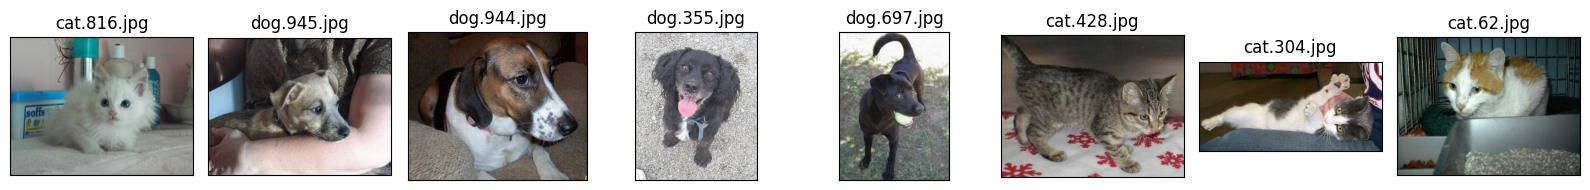

In [47]:
# Sample pets images
import random
fig, axs = plt.subplots(1, 8, figsize=(16, 2))

fnames = [fn for fn in os.listdir('dogs_vs_cats_1000')]
for ax, fname in zip(axs.ravel(), random.choices(fnames, k=8)):
    img_ = Image.open(os.path.join('dogs_vs_cats_1000', fname))
    ax.imshow(img_)
    ax.set_title(f"{fname}")
    ax.tick_params(left = False,labelleft = False , labelbottom = False, bottom = False)
plt.tight_layout()

In [48]:
# Here we generate image embeddings using the activations before the last layer
# use batches to accelerate the process

X_ = []  # storage for batches embeddings
Y_ = []  # storage for batches labels

filenames = sorted(fname for fname in os.listdir('dogs_vs_cats_1000')
                   if fname.lower().endswith(('.jpg', '.jpeg', '.png')))
batch_size = 64
x_batch_list = []  # to accumulate batch components

# kept batch normalization fixed while extracting features
embedding_model.eval()
with torch.no_grad():
    for i, fname in enumerate(tqdm(filenames)):
        img = Image.open(os.path.join("dogs_vs_cats_1000", fname)).convert("RGB")
        img_torch = transforms.ToTensor()(img.resize((224, 224)))
        # used imagenet normalization before feature extraction
        img_torch = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(img_torch)
        x_batch_list.append(img_torch)
        Y_.append(1 if fname.startswith("cat") else 0)

        if len(x_batch_list) == batch_size or i >= len(filenames) - 1:
            x_batch = torch.stack(x_batch_list)
            # use your embedding model to produce embeddings vectors, save results on CPU
            embeddings = embedding_model(x_batch.to(device)).cpu()

            assert isinstance(embeddings,  torch.Tensor) and embeddings.device.type == "cpu"
            assert embeddings.ndim == 2 and embeddings.shape[1] == 512
            X_.append(embeddings)
            x_batch_list = []

  0%|          | 0/2000 [00:00<?, ?it/s]

In [49]:
X = np.concatenate(X_, axis = 0)  # concatenate all batches' embeddings into single 2D array.
Y = np.array(Y_[:len(X)])  # convert labels into np array; crop if we ended prematurely

print(X.shape, Y.shape, np.mean(Y))

assert X.ndim == 2 and X.shape[1] == 512
assert X.shape[0] == len(filenames)
assert Y.ndim == 1 and Y.shape[0] == X.shape[0]
assert 0.49 <= np.mean(Y) <= 0.51

(2000, 512) (2000,) 0.5


### Using model embeddings as classifier features

Train sklearn model, evaluate validation accuracy (should be >90%)

In [50]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

__Task 1 (2 points): train the model and evaluate its accuracy on a hold-out set.__
- write the code for cats/dogs classification using the embeddings created above. Use any classification tools that you learned. Reach at least 95% accuracy. __(1 point)__.  Try few different tools if accuracy is not high enough. <br>
(You may choose any classifier algorithm as long as it gets above 95% accuracy. To get the max grade here, you need to tune main hyperparameters of your chosen algorithm (e.g. k for KNN, tree depth, logreg C) depending on how many data points you have. )
- try this excercise with much smaller training set. Find the lowest train set size at which you can still predict cat/dog class with 95% accuracy __(1 point)__ <br>
(note: exact threshold may depend on algorightm choice and train/test split. Show your effort in  experimenting with low train set sizes.)

In [51]:
%%time
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42, stratify=Y)

# selected c using only the training data
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, log_loss

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
classifier = GridSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42)),
    {'logisticregression__C': [0.01, 0.1, 1, 10, 100]},
    scoring='accuracy', cv=cv, n_jobs=1
)
classifier.fit(X_train, Y_train)
print('best parameters:', classifier.best_params_)
print(f'cross-validation accuracy = {classifier.best_score_:.2%}')

Y_pred = classifier.predict(X_test)
catdog_accuracy = accuracy_score(Y_test, Y_pred)
catdog_loss = log_loss(Y_test, classifier.predict_proba(X_test))
print(f'hold-out loss = {catdog_loss:.4f}')


print(f"accuracy = {(Y_pred == Y_test).sum() / Y_pred.shape[0]:.1%}")

best parameters: {'logisticregression__C': 1}
cross-validation accuracy = 98.61%
hold-out loss = 0.0718
accuracy = 97.5%
CPU times: user 6.13 s, sys: 45 ms, total: 6.18 s
Wall time: 3.22 s


### smaller training sets

Compared nested, balanced training subsets. Chose the smallest tested size reaching 95% in cross-validation before checking its hold-out accuracy. Small subsets give noisy estimates; this is not a universal minimum.

In [52]:
# compared smaller training sets without tuning on the hold-out set
size_results = []
small_classifier = None
smallest_size = None
small_data_cv = -1.0
rng = np.random.default_rng(42)
cat_indices = rng.permutation(np.flatnonzero(Y_train == 1))
dog_indices = rng.permutation(np.flatnonzero(Y_train == 0))

for train_size in [10, 20, 50, 100, 200, 500, 1000, len(X_train)]:
    indices = np.concatenate([cat_indices[:train_size // 2],
                              dog_indices[:train_size - train_size // 2]])
    search = GridSearchCV(
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42)),
        {'logisticregression__C': [0.01, 0.1, 1, 10, 100]},
        scoring='accuracy', cv=cv, n_jobs=1
    )
    search.fit(X_train[indices], Y_train[indices])
    size_results.append((len(indices), search.best_score_, search.best_params_['logisticregression__C']))
    print(f'train size = {len(indices)}, cv accuracy = {search.best_score_:.2%}, '
          f'c = {search.best_params_["logisticregression__C"]}')
    if smallest_size is None and search.best_score_ >= 0.95:
        smallest_size = len(indices)
        small_classifier = search.best_estimator_
        small_data_cv = search.best_score_

# evaluated the selected size once on the untouched hold-out set
small_data_accuracy = None
if small_classifier is not None:
    small_data_accuracy = accuracy_score(Y_test, small_classifier.predict(X_test))
    print(f'smallest tested size with cv accuracy >= 95%: {smallest_size}')
    print(f'hold-out accuracy for that size = {small_data_accuracy:.2%}')
    print(f'hold-out loss = {log_loss(Y_test, small_classifier.predict_proba(X_test)):.4f}')
    if small_data_accuracy < 0.95:
        print('the selected small training set did not reach 95% on hold-out data')
else:
    print('none of the tested sizes reached 95% cross-validation accuracy')

train size = 10, cv accuracy = 100.00%, c = 0.01
train size = 20, cv accuracy = 100.00%, c = 0.01
train size = 50, cv accuracy = 100.00%, c = 0.01
train size = 100, cv accuracy = 97.00%, c = 0.01
train size = 200, cv accuracy = 99.00%, c = 0.01
train size = 500, cv accuracy = 98.40%, c = 0.1
train size = 1000, cv accuracy = 98.50%, c = 0.1
train size = 1800, cv accuracy = 98.44%, c = 0.1
smallest tested size with cv accuracy >= 95%: 10
hold-out accuracy for that size = 95.00%
hold-out loss = 0.3578


## Torchvision Datasets
- Built-in datasets https://pytorch.org/vision/stable/datasets.html#built-in-datasets

- Datasets and Dataloaders at `torch.utils.data`: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

- Torchvision classes for custom datasets  https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets

# Problem 2: Clasification of cat/dog breeds using Oxford pets dataset

The next problem is to classify specific cat / dog breeds from popular Oxford pets dataset. It is conveniently provided by Pytorch so loading and using it is very easy.

Dataset home page: https://www.robots.ox.ac.uk/~vgg/data/pets/

Available from Pytorch: https://pytorch.org/vision/stable/generated/torchvision.datasets.OxfordIIITPet.html#torchvision.datasets.OxfordIIITPet



In [53]:
# Loading train and test subsets of the dataset
# using simple transform for both slices

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.OxfordIIITPet(root='.', split='trainval', target_types='category', download=True, transform=test_transform)
test_dataset = torchvision.datasets.OxfordIIITPet(root='.', split='test', target_types='category', download=True, transform=test_transform)

print("dataset sizes:", len(train_dataset), len(test_dataset))

print(train_dataset.classes)

dataset sizes: 3680 3669
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [54]:
# create dataloaders to repack the datasets' data into batches
# read more

# reserved 20% of trainval for validation and kept every breed in both splits
from torch.utils.data import Subset
pet_labels = np.array(train_dataset._labels)
train_indices, val_indices = train_test_split(
    np.arange(len(train_dataset)), test_size=0.2, random_state=42, stratify=pet_labels
)
assert set(train_indices).isdisjoint(val_indices)
assert len(train_indices) + len(val_indices) == len(train_dataset)
assert set(pet_labels[train_indices]) == set(pet_labels[val_indices])
train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)
print('train / validation / test:', len(train_subset), len(val_subset), len(test_dataset))

batch_size = 64
train_dataloader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("dataloader sizes:", len(train_dataloader), len(test_dataloader))

train / validation / test: 2944 736 3669
dataloader sizes: 46 58


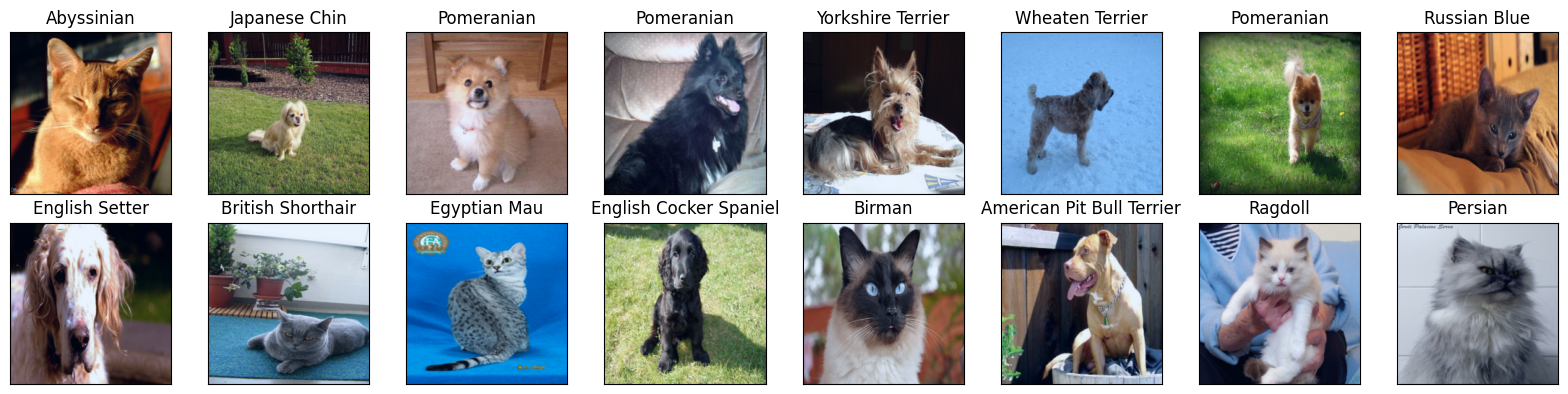

In [25]:
# Showing sample pets images
for x_batch, y_batch in train_dataloader:
    break  # Only get data from the 1st batch for now

fig, axs = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axs.ravel()):
    img_ = x_batch[i].permute(1, 2, 0) # restoring dimensions order
    img_ -= img_.min().item()  # normalizing image to 0..1
    img_ /= img_.max().item()
    ax.imshow(img_)
    label = train_dataset.classes[y_batch[i]]
    ax.set_title(f"{label}")
    ax.tick_params(left=False, labelleft=False, labelbottom=False, bottom=False)
plt.tight_layout()

Remember that Imagenet includes quite a few cat and dog breeds among its classes.

Let's try to predcit breeds with Imagenet-pretrained model without finetuning first

In [55]:
# Predicting breeds with Imagenet-pretrained model
# used validation images for this exploratory comparison
model.eval()
Y_probs, Y_true = [], []
for x_batch, y_batch in tqdm(val_dataloader):
    with torch.no_grad():
        prediction = model(x_batch.to(device))
        probs = torch.nn.functional.softmax(prediction, dim=-1).cpu()
        Y_true.append(y_batch)
        Y_probs.append(probs)

Y_probs = torch.cat(Y_probs, axis=0)  # tensor with class probabilities
Y_true = torch.cat(Y_true)
Y_true.shape, Y_probs.shape

  0%|          | 0/12 [00:00<?, ?it/s]

(torch.Size([736]), torch.Size([736, 1000]))

In [56]:
# Output top 3 predictions for each class using pretrained CNN (no finetuning)
# Expect to see high accuracy (70-80%) in some classes, much lower overal, mismatch in label spaces.

results_list = {}

for i, cl in enumerate(train_dataset.classes):
    class_stats = {"true_label":cl}
    probs1 = Y_probs[np.where(Y_true == i)].mean(axis=0).numpy()
    top_ix = probs1.argsort()[-1:][::-1]
    class_stats
    for j, l in enumerate(top_ix):
        class_stats = {f"pred_1": imagenet_labels[l],
                    f"prob_{1}": probs1.ravel()[l]}
    results_list[cl] = class_stats

df = pd.DataFrame(results_list).T.sort_values('prob_1', ascending=False)
float_cols = ['prob_1']
df.style.format('{:.2%}', subset=float_cols)

,pred_1,prob_1
Persian,Persian_cat,96.76%
Keeshond,keeshond,96.41%
Leonberger,Leonberg,92.77%
Siamese,Siamese_cat,92.41%
Pug,pug,90.29%
Saint Bernard,Saint_Bernard,86.04%
Pomeranian,Pomeranian,84.17%
Egyptian Mau,Egyptian_cat,80.64%
Samoyed,Samoyed,78.39%
Japanese Chin,Japanese_spaniel,72.64%


### Finetuning CNN: classification layer only:

__Task 2: (3 points)__:<br>
Complete the code below and reach at least 85% accuracy by training only the classification layer:

In [57]:
ft_model = deepcopy(model).to(device)

# froze the pretrained layers and replaced the classification layer
torch.manual_seed(42)
for parameter in ft_model.parameters():
    parameter.requires_grad = False
ft_model.fc = torch.nn.Linear(ft_model.fc.in_features, len(train_dataset.classes)).to(device)

# your task:
# 1) freeze all model parameters
# 2) replace model.fc with a new linear layer that has the appropriate number of outputs

assert all(not p.requires_grad for p in ft_model.parameters() if p not in set(ft_model.fc.parameters()))
assert ft_model.fc.out_features == len(train_dataset.classes)
assert ft_model.fc.weight.device == device, f"ft_model.fc must be on {device}"
assert ft_model.fc.weight.requires_grad

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ft_model.parameters(), lr=0.001)

In [58]:
# train the finetuning model in a standard training loop.

num_epochs = 10  # Adjust number of epochs if needed

history = defaultdict(list)
best_head_accuracy = -1.0
best_head_epoch = 0
for epoch in range(num_epochs):
    start_time = time.time()

    ft_model.train()
    # kept the frozen batch normalization statistics unchanged
    for layer in ft_model.modules():
        if isinstance(layer, torch.nn.BatchNorm2d):
            layer.eval()
    train_losses = []
    train_counts = []
    pbar = tqdm(train_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # calculate model predictions, calculate loss, make optimizer step
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        y_pred = ft_model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_counts.append(len(y_batch))
        pbar.desc = f"Train. Ep:{epoch}, Loss:{np.mean(train_losses[-10:]):.5f}"

    ft_model.eval()
    val_losses = []
    val_counts = []
    val_cnt, val_correct = 0, 0
    pbar = tqdm(val_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # get model predictions, measure loss, collect data for accuracy calc
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        with torch.no_grad():
            y_pred = ft_model(x_batch)
            loss = criterion(y_pred, y_batch)

        val_losses.append(loss.item())
        val_counts.append(len(y_batch))
        val_cnt += y_batch.shape[0]
        val_correct += (y_batch == torch.argmax(y_pred, dim=1)).sum().item()
        pbar.desc = f"Valid. Ep:{epoch}, Loss:{np.mean(val_losses):.5f}"

    train_loss = np.average(train_losses, weights=train_counts)
    val_loss = np.average(val_losses, weights=val_counts)
    accuracy = val_correct / val_cnt
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(accuracy)
    if accuracy > best_head_accuracy:
        best_head_accuracy = accuracy
        best_head_epoch = epoch + 1
        best_head_weights = {name: value.detach().cpu().clone()
                             for name, value in ft_model.state_dict().items()}
    print(f"Ep.{epoch:>2}: {train_loss=:.5f}  {val_loss=:.5f}  {accuracy=:.2%}  epoch_time={time.time() - start_time:.1f}s")

    if epoch > 2 and history['accuracy'][-1] < max(history['accuracy']):
        break
print(f"Best Accuracy = {max(history['accuracy']):.2%}")
# restored the best validation epoch, not the last epoch
last_head_accuracy = accuracy
ft_model.load_state_dict(best_head_weights)
ft_model.eval()
accuracy = best_head_accuracy
print(f'last head accuracy = {last_head_accuracy:.2%}; restored epoch {best_head_epoch}')

# kept this starting point for the full-network experiments
head_weights = deepcopy(best_head_weights)
head_model = deepcopy(ft_model).cpu()
head_history = deepcopy(history)
head_validation_accuracy = accuracy

  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 0: train_loss=2.29019  val_loss=1.23161  accuracy=78.67%  epoch_time=32.9s


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 4: train_loss=0.36431  val_loss=0.41566  accuracy=90.22%  epoch_time=33.2s


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 5: train_loss=0.30689  val_loss=0.40083  accuracy=89.27%  epoch_time=32.5s
Best Accuracy = 90.22%
last head accuracy = 89.27%; restored epoch 5


In [59]:
# This part of finetuning alone should deliver at least 85% accuracy.
assert accuracy > 0.85

In [60]:
# Predicting breeds with finetuned model

ft_model.eval()
Y_probs, Y_true = [], []
for x_batch, y_batch in tqdm(val_dataloader):
    with torch.no_grad():
        prediction = ft_model(x_batch.to(device))
        probs = torch.nn.functional.softmax(prediction, dim=-1).cpu()
        Y_true.append(y_batch)
        Y_probs.append(probs)

Y_probs = torch.cat(Y_probs, axis=0)
Y_true = torch.cat(Y_true)
Y_true.shape, Y_probs.shape

  0%|          | 0/12 [00:00<?, ?it/s]

(torch.Size([736]), torch.Size([736, 37]))

In [61]:
# Measure Top1 prediction accuracy for each class

results_list = {}
total, correct = 0, 0
# counted predicted classes instead of averaging probabilities
Y_pred = Y_probs.argmax(dim=1)

for i, cl in enumerate(train_dataset.classes):
    class_preds = np.where(Y_true == i)
    class_correct = (Y_pred[class_preds] == i).sum().item()
    acc1 = class_correct / class_preds[0].shape[0]
    class_stats = {"true_label":cl, 'acc1': acc1}
    total += class_preds[0].shape[0]
    correct += class_correct
    results_list[cl] = acc1

# separated the overall accuracy from the mean across breeds
micro_accuracy = correct / total
macro_accuracy = np.mean(list(results_list.values()))
print(f'micro accuracy = {micro_accuracy:.2%}')
print(f'macro accuracy = {macro_accuracy:.2%}')
df = pd.Series(results_list).to_frame('acc1').sort_values('acc1', ascending=False)
df.style.format('{:.2%}', subset=['acc1'])

micro accuracy = 90.22%
macro accuracy = 90.23%


,acc1
Beagle,100.00%
Great Pyrenees,100.00%
Maine Coon,100.00%
Egyptian Mau,100.00%
Bombay,100.00%
Samoyed,100.00%
Sphynx,100.00%
Wheaten Terrier,100.00%
Newfoundland,100.00%
Keeshond,100.00%


### Finetuning CNN: now unfreeze and train all layers:

__task 3 (5 points)__: Based on the previous task, continue finetuning the model run by training all of its layers. Obtain at least 90% accuracy (macro average, as defined in the code).
To reach 90%, you will need to experiment with network and/or training code, start from using improvements from the list below:

Scoring:
- reaching 90% accuracy - __3 points__
- testing out all 4 of these improvements - __2 points__:
    - Hyperparameters optimization
    - Image augmentation
    - Pretrained model selection
    - Early stopping training at epoch with best metric and / or loading the weights of best epoch. [read about `state_dict`](https://pytorch.org/tutorials/beginner/saving_loading_models.html#what-is-a-state-dict)
    
(you may not necessarily get spectacular results right away. Experiment and describe your actions and findings in a brief report in this notebook.)
- scoring above 90% -- __+1 BONUS point__ for every 1% improvement in accuracy above 90%

__Guidelines__: to improve quality of the finetuned model we can now train all of its layers.
- do this after initial training of classification layer
- set learning rate to much lower level to avoid explosion
- make all layers trainable using `requires_grad` param

In [62]:
# Continue training with all layers involved

# made all layers trainable for the next stage
for parameter in ft_model.parameters():
    parameter.requires_grad = True

assert all (p.requires_grad for p in ft_model.parameters())

optimizer = torch.optim.Adam(ft_model.parameters(), lr=0.00003)  # reduce LR to avoid explosion

# compared all runs on the same validation split
experiment_results = []
selected_model = None
selected_name = None
selected_macro_accuracy = -1.0
run_name = 'resnet18_baseline'

In [63]:
# train the finetuning model in a standard training loop.

num_epochs = 10  # Adjust number of epochs if needed

# fixed the seed for comparable shuffling across experiments
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
history = defaultdict(list)
best_val_macro = -1.0
best_epoch = 0
for epoch in range(num_epochs):
    start_time = time.time()

    ft_model.train()
    train_losses = []
    train_counts = []
    pbar = tqdm(train_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # calculate model predictions, calculate loss, make optimizer step
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        y_pred = ft_model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_counts.append(len(y_batch))
        pbar.desc = f"Train. Ep:{epoch}, Loss:{np.mean(train_losses[-10:]):.5f}"

    ft_model.eval()
    val_losses = []
    val_counts = []
    val_cnt, val_correct = 0, 0
    val_class_count = np.zeros(len(train_dataset.classes))
    val_class_correct = np.zeros(len(train_dataset.classes))
    pbar = tqdm(val_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # get model predictions, measure loss, collect data for accuracy calc
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        with torch.no_grad():
            y_pred = ft_model(x_batch)
            loss = criterion(y_pred, y_batch)

        val_losses.append(loss.item())
        val_counts.append(len(y_batch))
        val_cnt += y_batch.shape[0]
        val_correct += (y_batch == torch.argmax(y_pred, dim=1)).sum().item()
        labels_cpu = y_batch.cpu().numpy()
        predictions_cpu = y_pred.argmax(dim=1).cpu().numpy()
        val_class_count += np.bincount(labels_cpu, minlength=len(train_dataset.classes))
        val_class_correct += np.bincount(
            labels_cpu[labels_cpu == predictions_cpu], minlength=len(train_dataset.classes)
        )
        pbar.desc = f"Valid. Ep:{epoch}, Loss:{np.mean(val_losses):.5f}"

    train_loss = np.average(train_losses, weights=train_counts)
    val_loss = np.average(val_losses, weights=val_counts)
    accuracy = val_correct / val_cnt
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(accuracy)
    macro_accuracy = np.mean(val_class_correct / val_class_count)
    history['macro_accuracy'].append(macro_accuracy)
    if macro_accuracy > best_val_macro:
        best_val_macro = macro_accuracy
        best_epoch = epoch + 1
        best_val_micro = accuracy
        best_val_loss = val_loss
        best_weights = {name: value.detach().cpu().clone()
                        for name, value in ft_model.state_dict().items()}
    print(f"Ep.{epoch:>2}: {train_loss=:.5f}  {val_loss=:.5f}  {accuracy=:.2%}  epoch_time={time.time() - start_time:.1f}s")

    print(f'{run_name}: validation macro accuracy = {macro_accuracy:.2%}')
    if epoch > 2 and history['macro_accuracy'][-1] < max(history['macro_accuracy']):
        break
print(f"Best Accuracy = {max(history['accuracy']):.2%}")
# compared the stopping epoch with the best epoch and restored the best weights
last_val_macro = history['macro_accuracy'][-1]
ft_model.load_state_dict(best_weights)
ft_model.eval()
experiment_results.append(dict(
    experiment=run_name, val_loss=best_val_loss, micro_accuracy=best_val_micro,
    macro_accuracy=best_val_macro, best_epoch=best_epoch, epochs_run=len(history['accuracy']),
    last_macro_accuracy=last_val_macro
))
print(f'{run_name}: last macro = {last_val_macro:.2%}; '
      f'best macro = {best_val_macro:.2%} at epoch {best_epoch}')
if best_val_macro > selected_macro_accuracy:
    selected_macro_accuracy = best_val_macro
    selected_name = run_name
    selected_model = deepcopy(ft_model).cpu()

  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 0: train_loss=0.38970  val_loss=0.35457  accuracy=90.76%  epoch_time=37.2s
resnet18_baseline: validation macro accuracy = 90.77%


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 2: train_loss=0.11151  val_loss=0.29973  accuracy=92.80%  epoch_time=36.4s
resnet18_baseline: validation macro accuracy = 92.80%


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 3: train_loss=0.07695  val_loss=0.28962  accuracy=92.66%  epoch_time=36.9s
resnet18_baseline: validation macro accuracy = 92.67%
Best Accuracy = 92.80%
resnet18_baseline: last macro = 92.67%; best macro = 92.80% at epoch 3


In [64]:
# Predicting breeds with finetuned model

ft_model.eval()
Y_probs, Y_true = [], []
for x_batch, y_batch in tqdm(val_dataloader):
    with torch.no_grad():
        prediction = ft_model(x_batch.to(device))
        probs = torch.nn.functional.softmax(prediction, dim=-1).cpu()
        Y_true.append(y_batch)
        Y_probs.append(probs)

Y_probs = torch.cat(Y_probs, axis=0)
Y_true = torch.cat(Y_true)
Y_true.shape, Y_probs.shape

# Measure Top1 prediction accuracy for each class

results_list = {}
total, correct = 0, 0
# counted predicted classes instead of averaging probabilities
Y_pred = Y_probs.argmax(dim=1)

for i, cl in enumerate(train_dataset.classes):
    class_preds = np.where(Y_true == i)
    class_correct = (Y_pred[class_preds] == i).sum().item()
    acc1 = class_correct / class_preds[0].shape[0]
    class_stats = {"true_label":cl, 'acc1': acc1}
    total += class_preds[0].shape[0]
    correct += class_correct
    results_list[cl] = acc1

# separated the overall accuracy from the mean across breeds
micro_accuracy = correct / total
macro_accuracy = np.mean(list(results_list.values()))
print(f'micro accuracy = {micro_accuracy:.2%}')
print(f'macro accuracy = {macro_accuracy:.2%}')
df = pd.Series(results_list).to_frame('acc1').sort_values('acc1', ascending=False)
df.style.format('{:.2%}', subset=['acc1'])

  0%|          | 0/12 [00:00<?, ?it/s]

micro accuracy = 92.80%
macro accuracy = 92.80%


,acc1
Beagle,100.00%
Great Pyrenees,100.00%
Maine Coon,100.00%
Leonberger,100.00%
Bombay,100.00%
Pug,100.00%
Sphynx,100.00%
Wheaten Terrier,100.00%
Newfoundland,100.00%
Keeshond,100.00%


In [65]:
# checked validation here and deferred the test threshold until after the experiments
print(f'baseline validation macro accuracy = {macro_accuracy:.2%}')
print(f'baseline validation micro accuracy = {micro_accuracy:.2%}')
print('the final 90% test check follows the experiment comparison')

baseline validation macro accuracy = 92.80%
baseline validation micro accuracy = 92.80%
the final 90% test check follows the experiment comparison


### experiment 1: learning rate

Compared `lr=0.00001` with the supplied `lr=0.00003`. Both full-network runs started from the same trained ResNet18 head checkpoint and used the same data and maximum of 10 epochs. No test scores were used to choose the learning rate.

In [66]:
# restarted from the same head checkpoint and changed only the learning rate
ft_model = deepcopy(head_model).to(device)
for parameter in ft_model.parameters():
    parameter.requires_grad = True
train_dataloader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(ft_model.parameters(), lr=0.00001)
run_name = 'resnet18_lower_lr'

In [67]:
# train the finetuning model in a standard training loop.

num_epochs = 10  # Adjust number of epochs if needed

# fixed the seed for comparable shuffling across experiments
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
history = defaultdict(list)
best_val_macro = -1.0
best_epoch = 0
for epoch in range(num_epochs):
    start_time = time.time()

    ft_model.train()
    train_losses = []
    train_counts = []
    pbar = tqdm(train_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # calculate model predictions, calculate loss, make optimizer step
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        y_pred = ft_model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_counts.append(len(y_batch))
        pbar.desc = f"Train. Ep:{epoch}, Loss:{np.mean(train_losses[-10:]):.5f}"

    ft_model.eval()
    val_losses = []
    val_counts = []
    val_cnt, val_correct = 0, 0
    val_class_count = np.zeros(len(train_dataset.classes))
    val_class_correct = np.zeros(len(train_dataset.classes))
    pbar = tqdm(val_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # get model predictions, measure loss, collect data for accuracy calc
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        with torch.no_grad():
            y_pred = ft_model(x_batch)
            loss = criterion(y_pred, y_batch)

        val_losses.append(loss.item())
        val_counts.append(len(y_batch))
        val_cnt += y_batch.shape[0]
        val_correct += (y_batch == torch.argmax(y_pred, dim=1)).sum().item()
        labels_cpu = y_batch.cpu().numpy()
        predictions_cpu = y_pred.argmax(dim=1).cpu().numpy()
        val_class_count += np.bincount(labels_cpu, minlength=len(train_dataset.classes))
        val_class_correct += np.bincount(
            labels_cpu[labels_cpu == predictions_cpu], minlength=len(train_dataset.classes)
        )
        pbar.desc = f"Valid. Ep:{epoch}, Loss:{np.mean(val_losses):.5f}"

    train_loss = np.average(train_losses, weights=train_counts)
    val_loss = np.average(val_losses, weights=val_counts)
    accuracy = val_correct / val_cnt
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(accuracy)
    macro_accuracy = np.mean(val_class_correct / val_class_count)
    history['macro_accuracy'].append(macro_accuracy)
    if macro_accuracy > best_val_macro:
        best_val_macro = macro_accuracy
        best_epoch = epoch + 1
        best_val_micro = accuracy
        best_val_loss = val_loss
        best_weights = {name: value.detach().cpu().clone()
                        for name, value in ft_model.state_dict().items()}
    print(f"Ep.{epoch:>2}: {train_loss=:.5f}  {val_loss=:.5f}  {accuracy=:.2%}  epoch_time={time.time() - start_time:.1f}s")

    print(f'{run_name}: validation macro accuracy = {macro_accuracy:.2%}')
    if epoch > 2 and history['macro_accuracy'][-1] < max(history['macro_accuracy']):
        break
print(f"Best Accuracy = {max(history['accuracy']):.2%}")
# compared the stopping epoch with the best epoch and restored the best weights
last_val_macro = history['macro_accuracy'][-1]
ft_model.load_state_dict(best_weights)
ft_model.eval()
experiment_results.append(dict(
    experiment=run_name, val_loss=best_val_loss, micro_accuracy=best_val_micro,
    macro_accuracy=best_val_macro, best_epoch=best_epoch, epochs_run=len(history['accuracy']),
    last_macro_accuracy=last_val_macro
))
print(f'{run_name}: last macro = {last_val_macro:.2%}; '
      f'best macro = {best_val_macro:.2%} at epoch {best_epoch}')
if best_val_macro > selected_macro_accuracy:
    selected_macro_accuracy = best_val_macro
    selected_name = run_name
    selected_model = deepcopy(ft_model).cpu()

  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 0: train_loss=0.44754  val_loss=0.43153  accuracy=90.49%  epoch_time=36.7s
resnet18_lower_lr: validation macro accuracy = 90.49%


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 7: train_loss=0.10395  val_loss=0.30627  accuracy=92.66%  epoch_time=36.8s
resnet18_lower_lr: validation macro accuracy = 92.67%


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 8: train_loss=0.09360  val_loss=0.29975  accuracy=92.26%  epoch_time=36.5s
resnet18_lower_lr: validation macro accuracy = 92.26%
Best Accuracy = 92.66%
resnet18_lower_lr: last macro = 92.26%; best macro = 92.67% at epoch 8


### experiment 2: augmentation

Compared random crops and horizontal flips with the baseline preprocessing. Used the same starting checkpoint and the original full-network learning rate, so this experiment changed only the training augmentation. Validation and test preprocessing stayed unchanged.

In [68]:
# augmented only the training subset and kept the original split
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
augmented_dataset = torchvision.datasets.OxfordIIITPet(
    root='.', split='trainval', target_types='category', download=False, transform=train_transform
)
assert np.array_equal(np.array(augmented_dataset._labels), pet_labels)
augmented_subset = Subset(augmented_dataset, train_indices)
train_dataloader = torch.utils.data.DataLoader(augmented_subset, batch_size=batch_size, shuffle=True)
ft_model = deepcopy(head_model).to(device)
for parameter in ft_model.parameters():
    parameter.requires_grad = True
optimizer = torch.optim.Adam(ft_model.parameters(), lr=0.00003)
run_name = 'resnet18_augmentation'

In [69]:
# train the finetuning model in a standard training loop.

num_epochs = 10  # Adjust number of epochs if needed

# fixed the seed for comparable shuffling across experiments
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
history = defaultdict(list)
best_val_macro = -1.0
best_epoch = 0
for epoch in range(num_epochs):
    start_time = time.time()

    ft_model.train()
    train_losses = []
    train_counts = []
    pbar = tqdm(train_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # calculate model predictions, calculate loss, make optimizer step
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        y_pred = ft_model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_counts.append(len(y_batch))
        pbar.desc = f"Train. Ep:{epoch}, Loss:{np.mean(train_losses[-10:]):.5f}"

    ft_model.eval()
    val_losses = []
    val_counts = []
    val_cnt, val_correct = 0, 0
    val_class_count = np.zeros(len(train_dataset.classes))
    val_class_correct = np.zeros(len(train_dataset.classes))
    pbar = tqdm(val_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # get model predictions, measure loss, collect data for accuracy calc
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        with torch.no_grad():
            y_pred = ft_model(x_batch)
            loss = criterion(y_pred, y_batch)

        val_losses.append(loss.item())
        val_counts.append(len(y_batch))
        val_cnt += y_batch.shape[0]
        val_correct += (y_batch == torch.argmax(y_pred, dim=1)).sum().item()
        labels_cpu = y_batch.cpu().numpy()
        predictions_cpu = y_pred.argmax(dim=1).cpu().numpy()
        val_class_count += np.bincount(labels_cpu, minlength=len(train_dataset.classes))
        val_class_correct += np.bincount(
            labels_cpu[labels_cpu == predictions_cpu], minlength=len(train_dataset.classes)
        )
        pbar.desc = f"Valid. Ep:{epoch}, Loss:{np.mean(val_losses):.5f}"

    train_loss = np.average(train_losses, weights=train_counts)
    val_loss = np.average(val_losses, weights=val_counts)
    accuracy = val_correct / val_cnt
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(accuracy)
    macro_accuracy = np.mean(val_class_correct / val_class_count)
    history['macro_accuracy'].append(macro_accuracy)
    if macro_accuracy > best_val_macro:
        best_val_macro = macro_accuracy
        best_epoch = epoch + 1
        best_val_micro = accuracy
        best_val_loss = val_loss
        best_weights = {name: value.detach().cpu().clone()
                        for name, value in ft_model.state_dict().items()}
    print(f"Ep.{epoch:>2}: {train_loss=:.5f}  {val_loss=:.5f}  {accuracy=:.2%}  epoch_time={time.time() - start_time:.1f}s")

    print(f'{run_name}: validation macro accuracy = {macro_accuracy:.2%}')
    if epoch > 2 and history['macro_accuracy'][-1] < max(history['macro_accuracy']):
        break
print(f"Best Accuracy = {max(history['accuracy']):.2%}")
# compared the stopping epoch with the best epoch and restored the best weights
last_val_macro = history['macro_accuracy'][-1]
ft_model.load_state_dict(best_weights)
ft_model.eval()
experiment_results.append(dict(
    experiment=run_name, val_loss=best_val_loss, micro_accuracy=best_val_micro,
    macro_accuracy=best_val_macro, best_epoch=best_epoch, epochs_run=len(history['accuracy']),
    last_macro_accuracy=last_val_macro
))
print(f'{run_name}: last macro = {last_val_macro:.2%}; '
      f'best macro = {best_val_macro:.2%} at epoch {best_epoch}')
if best_val_macro > selected_macro_accuracy:
    selected_macro_accuracy = best_val_macro
    selected_name = run_name
    selected_model = deepcopy(ft_model).cpu()

  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 0: train_loss=0.38322  val_loss=0.35881  accuracy=91.03%  epoch_time=34.0s
resnet18_augmentation: validation macro accuracy = 91.03%


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 2: train_loss=0.16155  val_loss=0.29836  accuracy=92.26%  epoch_time=34.3s
resnet18_augmentation: validation macro accuracy = 92.26%


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 3: train_loss=0.12125  val_loss=0.28346  accuracy=92.26%  epoch_time=34.5s
resnet18_augmentation: validation macro accuracy = 92.26%
Best Accuracy = 92.26%
resnet18_augmentation: last macro = 92.26%; best macro = 92.26% at epoch 3


### experiment 3: pretrained model

Compared pretrained ResNet34 with the ResNet18 baseline. Trained the new head first, then unfroze all layers. Used the baseline preprocessing, batch size and learning rates. The model and its pretrained weights changed together; their individual effects cannot be separated.

In [70]:
# replaced resnet18 with pretrained resnet34 and kept the baseline settings
from torchvision.models import resnet34, ResNet34_Weights
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
ft_model = resnet34(weights=ResNet34_Weights.DEFAULT).to(device)
for parameter in ft_model.parameters():
    parameter.requires_grad = False
torch.manual_seed(42)
ft_model.fc = torch.nn.Linear(ft_model.fc.in_features, len(train_dataset.classes)).to(device)
train_dataloader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(ft_model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 205MB/s]


In [71]:
# train the finetuning model in a standard training loop.

num_epochs = 10  # Adjust number of epochs if needed

history = defaultdict(list)
best_head_accuracy = -1.0
best_head_epoch = 0
for epoch in range(num_epochs):
    start_time = time.time()

    ft_model.train()
    # kept the frozen batch normalization statistics unchanged
    for layer in ft_model.modules():
        if isinstance(layer, torch.nn.BatchNorm2d):
            layer.eval()
    train_losses = []
    train_counts = []
    pbar = tqdm(train_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # calculate model predictions, calculate loss, make optimizer step
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        y_pred = ft_model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_counts.append(len(y_batch))
        pbar.desc = f"Train. Ep:{epoch}, Loss:{np.mean(train_losses[-10:]):.5f}"

    ft_model.eval()
    val_losses = []
    val_counts = []
    val_cnt, val_correct = 0, 0
    pbar = tqdm(val_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # get model predictions, measure loss, collect data for accuracy calc
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        with torch.no_grad():
            y_pred = ft_model(x_batch)
            loss = criterion(y_pred, y_batch)

        val_losses.append(loss.item())
        val_counts.append(len(y_batch))
        val_cnt += y_batch.shape[0]
        val_correct += (y_batch == torch.argmax(y_pred, dim=1)).sum().item()
        pbar.desc = f"Valid. Ep:{epoch}, Loss:{np.mean(val_losses):.5f}"

    train_loss = np.average(train_losses, weights=train_counts)
    val_loss = np.average(val_losses, weights=val_counts)
    accuracy = val_correct / val_cnt
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(accuracy)
    if accuracy > best_head_accuracy:
        best_head_accuracy = accuracy
        best_head_epoch = epoch + 1
        best_head_weights = {name: value.detach().cpu().clone()
                             for name, value in ft_model.state_dict().items()}
    print(f"Ep.{epoch:>2}: {train_loss=:.5f}  {val_loss=:.5f}  {accuracy=:.2%}  epoch_time={time.time() - start_time:.1f}s")

    if epoch > 2 and history['accuracy'][-1] < max(history['accuracy']):
        break
print(f"Best Accuracy = {max(history['accuracy']):.2%}")
# restored the best validation epoch, not the last epoch
last_head_accuracy = accuracy
ft_model.load_state_dict(best_head_weights)
ft_model.eval()
accuracy = best_head_accuracy
print(f'last head accuracy = {last_head_accuracy:.2%}; restored epoch {best_head_epoch}')

  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 0: train_loss=2.21324  val_loss=1.11686  accuracy=79.89%  epoch_time=32.7s


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 3: train_loss=0.36496  val_loss=0.40376  accuracy=90.90%  epoch_time=33.1s


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 4: train_loss=0.30092  val_loss=0.36779  accuracy=89.81%  epoch_time=33.1s
Best Accuracy = 90.90%
last head accuracy = 89.81%; restored epoch 4


In [72]:
# unfroze the alternative model and used the supplied full-network learning rate
for parameter in ft_model.parameters():
    parameter.requires_grad = True
optimizer = torch.optim.Adam(ft_model.parameters(), lr=0.00003)
run_name = 'resnet34_baseline'

In [73]:
# train the finetuning model in a standard training loop.

num_epochs = 10  # Adjust number of epochs if needed

# fixed the seed for comparable shuffling across experiments
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
history = defaultdict(list)
best_val_macro = -1.0
best_epoch = 0
for epoch in range(num_epochs):
    start_time = time.time()

    ft_model.train()
    train_losses = []
    train_counts = []
    pbar = tqdm(train_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # calculate model predictions, calculate loss, make optimizer step
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        y_pred = ft_model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_counts.append(len(y_batch))
        pbar.desc = f"Train. Ep:{epoch}, Loss:{np.mean(train_losses[-10:]):.5f}"

    ft_model.eval()
    val_losses = []
    val_counts = []
    val_cnt, val_correct = 0, 0
    val_class_count = np.zeros(len(train_dataset.classes))
    val_class_correct = np.zeros(len(train_dataset.classes))
    pbar = tqdm(val_dataloader, leave=False)
    for x_batch, y_batch in pbar:

        # get model predictions, measure loss, collect data for accuracy calc
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        with torch.no_grad():
            y_pred = ft_model(x_batch)
            loss = criterion(y_pred, y_batch)

        val_losses.append(loss.item())
        val_counts.append(len(y_batch))
        val_cnt += y_batch.shape[0]
        val_correct += (y_batch == torch.argmax(y_pred, dim=1)).sum().item()
        labels_cpu = y_batch.cpu().numpy()
        predictions_cpu = y_pred.argmax(dim=1).cpu().numpy()
        val_class_count += np.bincount(labels_cpu, minlength=len(train_dataset.classes))
        val_class_correct += np.bincount(
            labels_cpu[labels_cpu == predictions_cpu], minlength=len(train_dataset.classes)
        )
        pbar.desc = f"Valid. Ep:{epoch}, Loss:{np.mean(val_losses):.5f}"

    train_loss = np.average(train_losses, weights=train_counts)
    val_loss = np.average(val_losses, weights=val_counts)
    accuracy = val_correct / val_cnt
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(accuracy)
    macro_accuracy = np.mean(val_class_correct / val_class_count)
    history['macro_accuracy'].append(macro_accuracy)
    if macro_accuracy > best_val_macro:
        best_val_macro = macro_accuracy
        best_epoch = epoch + 1
        best_val_micro = accuracy
        best_val_loss = val_loss
        best_weights = {name: value.detach().cpu().clone()
                        for name, value in ft_model.state_dict().items()}
    print(f"Ep.{epoch:>2}: {train_loss=:.5f}  {val_loss=:.5f}  {accuracy=:.2%}  epoch_time={time.time() - start_time:.1f}s")

    print(f'{run_name}: validation macro accuracy = {macro_accuracy:.2%}')
    if epoch > 2 and history['macro_accuracy'][-1] < max(history['macro_accuracy']):
        break
print(f"Best Accuracy = {max(history['accuracy']):.2%}")
# compared the stopping epoch with the best epoch and restored the best weights
last_val_macro = history['macro_accuracy'][-1]
ft_model.load_state_dict(best_weights)
ft_model.eval()
experiment_results.append(dict(
    experiment=run_name, val_loss=best_val_loss, micro_accuracy=best_val_micro,
    macro_accuracy=best_val_macro, best_epoch=best_epoch, epochs_run=len(history['accuracy']),
    last_macro_accuracy=last_val_macro
))
print(f'{run_name}: last macro = {last_val_macro:.2%}; '
      f'best macro = {best_val_macro:.2%} at epoch {best_epoch}')
if best_val_macro > selected_macro_accuracy:
    selected_macro_accuracy = best_val_macro
    selected_name = run_name
    selected_model = deepcopy(ft_model).cpu()

  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 0: train_loss=0.34192  val_loss=0.29448  accuracy=91.30%  epoch_time=42.3s
resnet34_baseline: validation macro accuracy = 91.32%


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 2: train_loss=0.05368  val_loss=0.24865  accuracy=92.80%  epoch_time=43.0s
resnet34_baseline: validation macro accuracy = 92.80%


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Ep. 3: train_loss=0.03205  val_loss=0.24032  accuracy=92.80%  epoch_time=42.9s
resnet34_baseline: validation macro accuracy = 92.81%
Best Accuracy = 92.80%
resnet34_baseline: last macro = 92.81%; best macro = 92.81% at epoch 2


### experiment 4: early stopping and best weights

Kept the supplied early-stopping rule: after the first three epochs, stopped when the current score was below the previous maximum. For full-network training, used validation macro accuracy instead of micro accuracy to match Task 3. Recorded both the stopping epoch's macro accuracy and the best epoch's macro accuracy, and restored the best weights. The comparison below shows the effect of checkpoint restoration within each run; it is not a separate controlled test of early stopping versus a fixed training duration.

In [74]:
# compared the measured validation scores and selected a model without using test data
for row in experiment_results:
    print(f'{row["experiment"]}: loss = {row["val_loss"]:.4f}, '
          f'micro = {row["micro_accuracy"]:.2%}, macro = {row["macro_accuracy"]:.2%}, '
          f'best epoch = {row["best_epoch"]}/{row["epochs_run"]}')
    print(f'last epoch macro = {row["last_macro_accuracy"]:.2%}; '
          f'restored best macro = {row["macro_accuracy"]:.2%}')
print(f'selected model: {selected_name}, validation macro = {selected_macro_accuracy:.2%}')

resnet18_baseline: loss = 0.2997, micro = 92.80%, macro = 92.80%, best epoch = 3/4
last epoch macro = 92.67%; restored best macro = 92.80%
resnet18_lower_lr: loss = 0.3063, micro = 92.66%, macro = 92.67%, best epoch = 8/9
last epoch macro = 92.26%; restored best macro = 92.67%
resnet18_augmentation: loss = 0.2984, micro = 92.26%, macro = 92.26%, best epoch = 3/4
last epoch macro = 92.26%; restored best macro = 92.26%
resnet34_baseline: loss = 0.2637, micro = 92.80%, macro = 92.81%, best epoch = 2/4
last epoch macro = 92.81%; restored best macro = 92.81%
selected model: resnet34_baseline, validation macro = 92.81%


### final test

Evaluated the ResNet18 head-only model for Task 2 and the validation-selected full-network model for Task 3. Test scores were not used for selecting experiments or checkpoints. Do not use these scores to choose further changes.

In [75]:
# evaluated the fixed head-only checkpoint on test data
ft_model = deepcopy(head_model).to(device)
# Predicting breeds with finetuned model

ft_model.eval()
Y_probs, Y_true = [], []
for x_batch, y_batch in tqdm(test_dataloader):
    with torch.no_grad():
        prediction = ft_model(x_batch.to(device))
        probs = torch.nn.functional.softmax(prediction, dim=-1).cpu()
        Y_true.append(y_batch)
        Y_probs.append(probs)

Y_probs = torch.cat(Y_probs, axis=0)
Y_true = torch.cat(Y_true)
Y_true.shape, Y_probs.shape

# Measure Top1 prediction accuracy for each class

results_list = {}
total, correct = 0, 0
# counted predicted classes instead of averaging probabilities
Y_pred = Y_probs.argmax(dim=1)

for i, cl in enumerate(train_dataset.classes):
    class_preds = np.where(Y_true == i)
    class_correct = (Y_pred[class_preds] == i).sum().item()
    acc1 = class_correct / class_preds[0].shape[0]
    class_stats = {"true_label":cl, 'acc1': acc1}
    total += class_preds[0].shape[0]
    correct += class_correct
    results_list[cl] = acc1

# separated the overall accuracy from the mean across breeds
micro_accuracy = correct / total
macro_accuracy = np.mean(list(results_list.values()))
print(f'micro accuracy = {micro_accuracy:.2%}')
print(f'macro accuracy = {macro_accuracy:.2%}')
df = pd.Series(results_list).to_frame('acc1').sort_values('acc1', ascending=False)
df.style.format('{:.2%}', subset=['acc1'])
head_test_micro = micro_accuracy
head_test_macro = macro_accuracy
print(f'head-only test accuracy = {head_test_micro:.2%}')

  0%|          | 0/58 [00:00<?, ?it/s]

micro accuracy = 88.39%
macro accuracy = 88.33%
head-only test accuracy = 88.39%


In [76]:
# evaluated the validation-selected full-network model on test data
ft_model = deepcopy(selected_model).to(device)
# Predicting breeds with finetuned model

ft_model.eval()
Y_probs, Y_true = [], []
for x_batch, y_batch in tqdm(test_dataloader):
    with torch.no_grad():
        prediction = ft_model(x_batch.to(device))
        probs = torch.nn.functional.softmax(prediction, dim=-1).cpu()
        Y_true.append(y_batch)
        Y_probs.append(probs)

Y_probs = torch.cat(Y_probs, axis=0)
Y_true = torch.cat(Y_true)
Y_true.shape, Y_probs.shape

# Measure Top1 prediction accuracy for each class

results_list = {}
total, correct = 0, 0
# counted predicted classes instead of averaging probabilities
Y_pred = Y_probs.argmax(dim=1)

for i, cl in enumerate(train_dataset.classes):
    class_preds = np.where(Y_true == i)
    class_correct = (Y_pred[class_preds] == i).sum().item()
    acc1 = class_correct / class_preds[0].shape[0]
    class_stats = {"true_label":cl, 'acc1': acc1}
    total += class_preds[0].shape[0]
    correct += class_correct
    results_list[cl] = acc1

# separated the overall accuracy from the mean across breeds
micro_accuracy = correct / total
macro_accuracy = np.mean(list(results_list.values()))
print(f'micro accuracy = {micro_accuracy:.2%}')
print(f'macro accuracy = {macro_accuracy:.2%}')
df = pd.Series(results_list).to_frame('acc1').sort_values('acc1', ascending=False)
df.style.format('{:.2%}', subset=['acc1'])
full_test_micro = micro_accuracy
full_test_macro = macro_accuracy
print(f'{selected_name}: test micro = {full_test_micro:.2%}, test macro = {full_test_macro:.2%}')

  0%|          | 0/58 [00:00<?, ?it/s]

micro accuracy = 90.87%
macro accuracy = 90.80%
resnet34_baseline: test micro = 90.87%, test macro = 90.80%


In [77]:
print(f"Overall Accuracy = {macro_accuracy:.2%}")  # macro-averaged accuracy
assert macro_accuracy >= 0.9
print(f'Micro Accuracy = {micro_accuracy:.2%}')
assert head_test_micro > 0.85, 'the head-only model did not reach the task 2 test target'

Overall Accuracy = 90.80%
Micro Accuracy = 90.87%


# STUDENT'S REPORT

Please write a short report describing the steps you took to improve quality. It should be at least a short paragraph with 3-5 sentences and, optionally, any relevant numbers/charts, but there's no upper limit.

I used a pretrained ResNet18 to extract image features and trained logistic regression to classify cats and dogs. I selected the logistic regression C parameter using five-fold cross-validation on the training data. With C=1, the classifier reached 98.61% cross-validation accuracy and 97.5% hold-out accuracy, with a hold-out loss of 0.0718.

I also tested smaller, balanced training subsets. The smallest tested subset contained 10 images and reached 95% hold-out accuracy, with a loss of 0.3578. Its cross-validation accuracy was 100%, but estimates from such small samples are noisy. This does not mean that 10 images will be sufficient for another data split.

For Oxford Pets, I reserved a stratified 20% of trainval for validation: 2,944 training images and 736 validation images. I kept the official 3,669 test images for final evaluation. I changed the exploratory predictions and training checks to use validation instead of test, and moved the final test check after the experiments.

I first froze the ResNet18 backbone and trained only the new classification layer. I also kept BatchNorm running statistics fixed. I used the supplied batch size of 64, a maximum of 10 epochs and Adam with a learning rate of 0.001. The best checkpoint came from epoch 5 and reached 90.22% validation accuracy. Its final test accuracy was 88.39%, exceeding the 85% target.

Next, I unfroze all layers and used the supplied learning rate of 0.00003. The baseline ResNet18 reached 92.80% validation macro accuracy at epoch 3 and stopped after epoch 4. I then tested a lower learning rate, augmentation and another pretrained model in separate experiments.

Reducing the learning rate to 0.00001 gave 92.67% validation macro accuracy at epoch 8, with training stopping after epoch 9. It required more epochs but did not improve the result. Adding random resized crops and horizontal flips gave 92.26% at epoch 3, with training stopping after epoch 4. Augmentation did not help in this setup, but this does not mean it is generally harmful. Both ResNet18 experiments started from the same trained head checkpoint as the baseline.

I also tested pretrained ResNet34 using the same head-only and full-network training stages. It reached 92.81% validation macro accuracy at epoch 2 and stopped after epoch 4. This was the highest validation score, although the difference from ResNet18 was very small and does not establish a reliable performance advantage.

For full-network training, I used macro accuracy for stopping and checkpoint selection. Restoring the best ResNet18 baseline checkpoint improved validation macro accuracy from 92.67% at the stopping epoch to 92.80%. For the lower-learning-rate experiment, it improved from 92.26% to 92.67%. This shows the effect of restoring weights, not an isolated comparison of early stopping against a fixed training duration.

I selected ResNet34 using validation results only. Its final test results were 90.80% macro accuracy and 90.87% micro accuracy, exceeding the 90% target. Macro accuracy was the unweighted mean of per-breed accuracies, while micro accuracy was the proportion of correct predictions across all test images.

# Bonus task __(optional. 2 more points)__:

Notice that accuracy varies across breeds. Build confusion Propose improvements to the model finetuning process to improve minimal accuracy levels for all classes. Show the model runs.
Measure the improvement in terms of minimal accuracy and micro-averaged accuracy.

# EXTRA STUFF:


## Links:    
- [The Building Blocks of Interpretability](https://distill.pub/2018/building-blocks/)
- [Activations Atlas](https://distill.pub/2019/activation-atlas/)
- more models from https://github.com/huggingface/pytorch-image-models
- Papers with code: benchmarks and model references. https://paperswithcode.com/sota/image-classification-on-imagenet